# Task7: Ramsey and Spin Echo under 1/f HEOM Noise

The two configured experiments are Ramsey `pi/2 - delay - pi/2 - measure` and spin echo `pi/2 - delay/2 - pi - delay/2 - pi/2 - measure`. The delay is implemented by the QASM `id` gate, whose duration is controlled by `pulse.idle_duration_ns`.

In [17]:
from pathlib import Path
import csv
import json

import matplotlib.pyplot as plt
import numpy as np

from musiq.workflow import create_model

ROOT = Path.cwd()
BASE = ROOT / "examples" / "noise_simulation_tests" / "task7"
if not BASE.exists():
    BASE = ROOT / "task7"
OUT = BASE.parent / "runs" / "task7_heom_1overf_spin_echo"
OUT.mkdir(parents=True, exist_ok=True)
DELAY_NS = list(np.linspace(0.0, 9000.0, 31))
BASE

WindowsPath('d:/閻℃帒鎳庨閬嶆煂韫囨挾鎽嶉悹渚婄磿閻ｅ寮甸崫鍕彣濠㈠湱澧楁慨鍌炲礆?MuSIQ/examples/noise_simulation_tests/task7')

In [18]:
def run_case(task_name, sequence, delay_ns):
    model = create_model(task_config=BASE / task_name)
    idle_duration_ns = 0.5 * delay_ns if sequence == "echo" else delay_ns
    model.pulse["idle_duration_ns"] = float(idle_duration_ns)
    model.run_all()
    
    traj = model.results.trajectories["solver_0"]
    rho = np.asarray(traj.density_matrix["snapshots"][-1], dtype=complex)
    return {
        "sequence": sequence,
        "delay_ns": float(delay_ns),
        "idle_duration_ns": float(idle_duration_ns),
        "p1": float(np.real(rho[1, 1])),
        "coherence_abs": float(abs(rho[0, 1])),
        "out_dir": str(model.out_dir),
    }

rows = []
for delay_ns in DELAY_NS:
    rows.append(run_case("task_ramsey.yaml", "ramsey", delay_ns))
    rows.append(run_case("task_echo.yaml", "echo", delay_ns))

csv_path = OUT / "delay_sweep.csv"
with csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0]))
    writer.writeheader()
    writer.writerows(rows)
(OUT / "summary.json").write_text(json.dumps({"rows": rows}, indent=2), encoding="utf-8")
rows[:4]

[{'sequence': 'ramsey',
  'delay_ns': 0.0,
  'idle_duration_ns': 0.0,
  'p1': 0.9973575803094188,
  'coherence_abs': 0.023856832872962346,
  'out_dir': 'D:\\閻℃帒鎳庨閬嶆煂韫囨挾鎽嶉悹渚婄磿閻ｅ寮甸崫鍕彣濠㈠湱澧楁慨鍌炲礆缁傜浂\MuSIQ\\examples\\noise_simulation_tests\\runs\\task7_ramsey_1overf_heom'},
 {'sequence': 'echo',
  'delay_ns': 0.0,
  'idle_duration_ns': 0.0,
  'p1': 0.9969098260177879,
  'coherence_abs': 0.025953567385776897,
  'out_dir': 'D:\\閻℃帒鎳庨閬嶆煂韫囨挾鎽嶉悹渚婄磿閻ｅ寮甸崫鍕彣濠㈠湱澧楁慨鍌炲礆缁傜浂\MuSIQ\\examples\\noise_simulation_tests\\runs\\task7_spin_echo_1overf_heom'},
 {'sequence': 'ramsey',
  'delay_ns': 300.0,
  'idle_duration_ns': 300.0,
  'p1': 0.9893197007507241,
  'coherence_abs': 0.0345751715338775,
  'out_dir': 'D:\\閻℃帒鎳庨閬嶆煂韫囨挾鎽嶉悹渚婄磿閻ｅ寮甸崫鍕彣濠㈠湱澧楁慨鍌炲礆缁傜浂\MuSIQ\\examples\\noise_simulation_tests\\runs\\task7_ramsey_1overf_heom'},
 {'sequence': 'echo',
  'delay_ns': 300.0,
  'idle_duration_ns': 150.0,
  'p1': 0.9909689867030542,
  'coherence_abs': 0.025301885659066662,
  'out_dir': 'D:\\閻℃帒鎳庨閬嶆煂韫囨挾鎽嶉悹渚婄磿閻ｅ寮

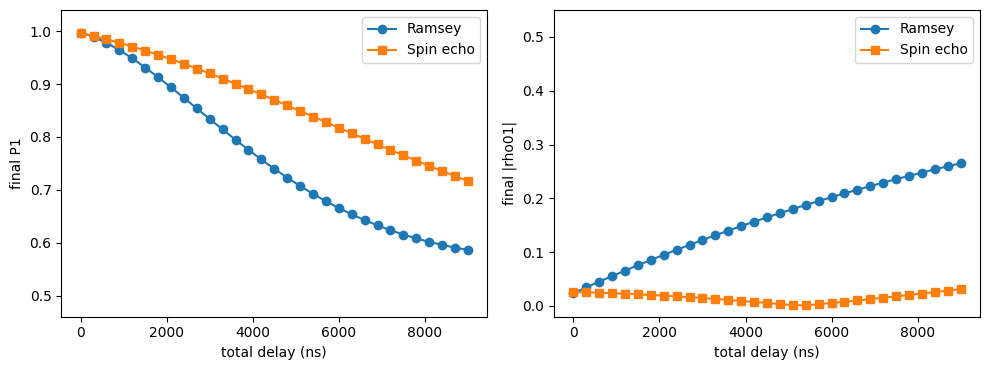

In [19]:
ramsey = [r for r in rows if r["sequence"] == "ramsey"]
echo = [r for r in rows if r["sequence"] == "echo"]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot([r["delay_ns"] for r in ramsey], [r["p1"] for r in ramsey], "o-", label="Ramsey")
ax[0].plot([r["delay_ns"] for r in echo], [r["p1"] for r in echo], "s-", label="Spin echo")
ax[0].set_xlabel("total delay (ns)")
ax[0].set_ylabel("final P1")
ax[0].set_ylim(0.46, 1.04)
ax[0].legend()

ax[1].plot([r["delay_ns"] for r in ramsey], [r["coherence_abs"] for r in ramsey], "o-", label="Ramsey")
ax[1].plot([r["delay_ns"] for r in echo], [r["coherence_abs"] for r in echo], "s-", label="Spin echo")
ax[1].set_xlabel("total delay (ns)")
ax[1].set_ylabel("final |rho01|")
ax[1].set_ylim(-0.02, 0.55)
ax[1].legend()

fig.tight_layout()
fig.savefig(OUT / "task7_delay_sweep.png", dpi=600)
plt.show()